<a href="https://colab.research.google.com/github/Ashu-42/quant_research_crypto_volatility_forecasting/blob/quant_DL_ashu/notebooks/06_LSTM_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
from pathlib import Path

import json
import random
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras import Sequential
from tensorflow.keras.layers import (
    Input,
    LSTM,
    Dense,
    Dropout,
)
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint,
)

In [2]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

try:
    tf.config.experimental.enable_op_determinism()
except Exception:
    pass

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


In [3]:
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
LOOKBACK_DAYS = 30

In [5]:
shared_project_dir = Path(
    "/content/drive/MyDrive/Quant Research"
)

btc_data_dir = (
    shared_project_dir
    / "data"
    / "model_ready"
    / "BTCUSDT"
    / f"lookback_{LOOKBACK_DAYS}d"
)

results_dir = (
    shared_project_dir
    / "results"
    / "BTCUSDT"
    / f"lookback_{LOOKBACK_DAYS}d"
    / "LSTM"
)

models_dir = (
    shared_project_dir
    / "models"
    / "BTCUSDT"
    / f"lookback_{LOOKBACK_DAYS}d"
    / "LSTM"
)

results_dir.mkdir(
    parents=True,
    exist_ok=True
)

models_dir.mkdir(
    parents=True,
    exist_ok=True
)

In [6]:
X_train = np.load(
    btc_data_dir / "X_train_scaled.npy"
)

X_val = np.load(
    btc_data_dir / "X_val_scaled.npy"
)

y_train = np.load(
    btc_data_dir / "y_train.npy"
)

y_val = np.load(
    btc_data_dir / "y_val.npy"
)

validation_metadata = pd.read_parquet(
    btc_data_dir
    / "validation_metadata.parquet"
)

with open(
    btc_data_dir / "dataset_configuration.json",
    "r",
    encoding="utf-8"
) as file:
    configuration = json.load(file)

In [7]:
print("Loaded dataset configuration:")
print("Candle interval:", configuration["candle_interval"])
print(
    "Variance definition:",
    configuration["variance_definition"]
)
print("Target:", configuration["target"])
print("Lookback:", configuration["lookback_days"])

assert (
    configuration["candle_interval"]
    == "1d"
)

assert (
    configuration["variance_definition"]
    == "squared_daily_log_return"
)

assert (
    int(configuration["lookback_days"])
    == LOOKBACK_DAYS
)

assert (
    configuration["target"]
    == "log_realized_variance"
)

print(
    "\nValidation period:",
    validation_metadata["target_date"].min(),
    "to",
    validation_metadata["target_date"].max()
)

print("\nShapes:")
print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("y_train:", y_train.shape)
print("y_val:", y_val.shape)

assert X_train.shape[0] == y_train.shape[0]
assert X_val.shape[0] == y_val.shape[0]
assert X_train.shape[1:] == X_val.shape[1:]
assert len(validation_metadata) == len(y_val)

Loaded dataset configuration:
Candle interval: 1d
Variance definition: squared_daily_log_return
Target: log_realized_variance
Lookback: 30

Validation period: 2024-08-01 00:00:00+00:00 to 2025-07-31 00:00:00+00:00

Shapes:
X_train: (2481, 30, 7)
X_val: (365, 30, 7)
y_train: (2481,)
y_val: (365,)


In [8]:
print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("y_train:", y_train.shape)
print("y_val:", y_val.shape)

assert X_train.shape[0] == y_train.shape[0]
assert X_val.shape[0] == y_val.shape[0]
assert X_train.shape[1:] == X_val.shape[1:]
assert len(validation_metadata) == len(y_val)

X_train: (2481, 30, 7)
X_val: (365, 30, 7)
y_train: (2481,)
y_val: (365,)


In [9]:
def build_lstm_model(
    lookback_days,
    n_features
):
    model = Sequential(
        [
            Input(
                shape=(
                    lookback_days,
                    n_features
                )
            ),

            LSTM(
                units=32,
                activation="tanh",
                recurrent_activation="sigmoid",
                return_sequences=False,
                dropout=0.0,
                recurrent_dropout=0.0,
            ),

            Dropout(rate=0.20),

            Dense(
                units=16,
                activation="relu"
            ),

            Dropout(rate=0.10),

            Dense(
                units=1,
                activation="linear"
            ),
        ],
        name="btc_lstm_log_rv"
    )

    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=0.001
        ),
        loss="mse",
        metrics=[
            tf.keras.metrics.MeanAbsoluteError(
                name="mae"
            )
        ]
    )

    return model

In [10]:
LOOKBACK_DAYS = X_train.shape[1]
N_FEATURES = X_train.shape[2]

lstm_model = build_lstm_model(
    lookback_days=LOOKBACK_DAYS,
    n_features=N_FEATURES
)

lstm_model.summary()

Model: "btc_lstm_log_rv"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 32)             │         5,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,665 (22.13 KB)

 Trainable params: 5,665 (22.13 KB)

 Non-trainable params: 0 (0.00 B)

In [11]:
best_model_path = (
    models_dir
    / "best_lstm_model.keras"
)

callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=15,
        restore_best_weights=True,
        min_delta=1e-4,
        verbose=1
    ),

    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=5,
        min_lr=1e-6,
        verbose=1
    ),

    ModelCheckpoint(
        filepath=best_model_path,
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    ),
]

In [12]:
history = lstm_model.fit(
    X_train,
    y_train,
    validation_data=(
        X_val,
        y_val
    ),
    epochs=200,
    batch_size=32,
    shuffle=False,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/200
74/78 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 71.4612 - mae: 8.0531
Epoch 1: val_loss improved from None to 36.77806, saving model to /content/drive/MyDrive/Quant Research/models/BTCUSDT/lookback_30d/LSTM/best_lstm_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Quant Research/models/BTCUSDT/lookback_30d/LSTM/best_lstm_model.keras
78/78 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - loss: 71.0823 - mae: 7.9727 - val_loss: 36.7781 - val_mae: 5.4815 - learning_rate: 0.0010
Epoch 2/200
76/78 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 16.7247 - mae: 3.3002
Epoch 2: val_loss improved from 36.77806 to 6.80948, saving model to /content/drive/MyDrive/Quant Research/models/BTCUSDT/lookback_30d/LSTM/best_lstm_model.keras

Epoch 2: finished saving model to /content/drive/MyDrive/Quant Research/models/BTCUSDT/lookback_30d/LSTM/best_lstm_model.keras
78/78 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - loss: 12.6500 - mae: 2.7661 - val_loss: 6.8095 - val_mae: 1.9691 - learning_rate: 0.0

In [13]:
history_df = pd.DataFrame(
    history.history
)

history_df["epoch"] = (
    np.arange(len(history_df)) + 1
)

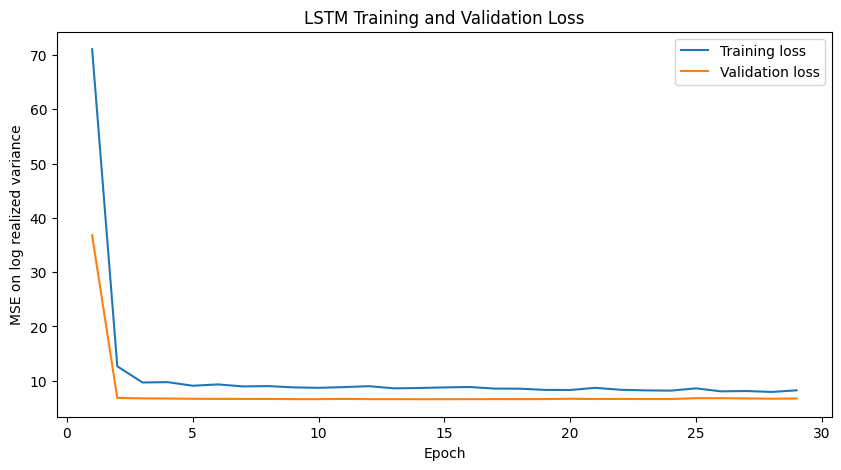

In [14]:
plt.figure(figsize=(10, 5))

plt.plot(
    history_df["epoch"],
    history_df["loss"],
    label="Training loss"
)

plt.plot(
    history_df["epoch"],
    history_df["val_loss"],
    label="Validation loss"
)

plt.xlabel("Epoch")
plt.ylabel("MSE on log realized variance")
plt.title("LSTM Training and Validation Loss")
plt.legend()
plt.show()

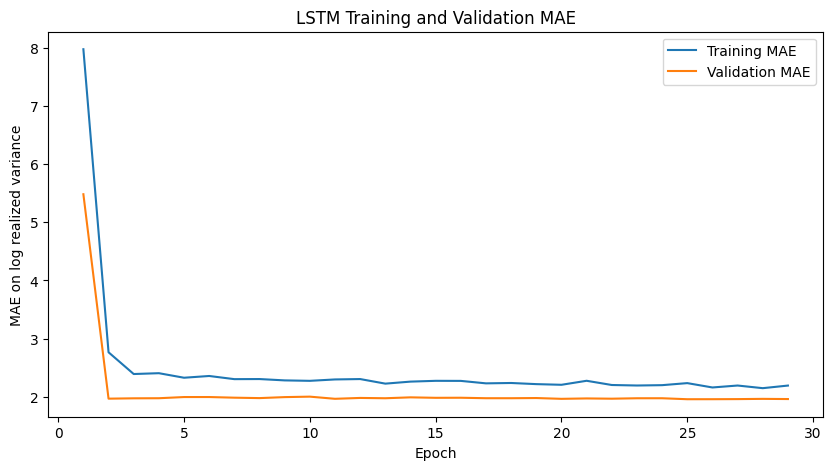

In [15]:
plt.figure(figsize=(10, 5))

plt.plot(
    history_df["epoch"],
    history_df["mae"],
    label="Training MAE"
)

plt.plot(
    history_df["epoch"],
    history_df["val_mae"],
    label="Validation MAE"
)

plt.xlabel("Epoch")
plt.ylabel("MAE on log realized variance")
plt.title("LSTM Training and Validation MAE")
plt.legend()
plt.show()

In [16]:
lstm_pred_log_rv = (
    lstm_model.predict(
        X_val,
        batch_size=32,
        verbose=0
    )
    .reshape(-1)
)

lstm_pred_rv = np.exp(
    lstm_pred_log_rv
)

actual_rv = validation_metadata[
    "actual_rv"
].to_numpy()

In [17]:
assert len(lstm_pred_rv) == len(actual_rv)
assert np.isfinite(lstm_pred_log_rv).all()
assert np.isfinite(lstm_pred_rv).all()
assert (lstm_pred_rv > 0).all()

print("Prediction checks passed.")

Prediction checks passed.


In [18]:
def mean_absolute_error(
    y_true,
    y_pred
):
    return np.mean(
        np.abs(
            np.asarray(y_true)
            - np.asarray(y_pred)
        )
    )


def root_mean_squared_error(
    y_true,
    y_pred
):
    return np.sqrt(
        np.mean(
            (
                np.asarray(y_true)
                - np.asarray(y_pred)
            ) ** 2
        )
    )


def qlike(
    y_true,
    y_pred,
    epsilon=1e-12
):
    y_true = np.maximum(
        np.asarray(y_true),
        epsilon
    )

    y_pred = np.maximum(
        np.asarray(y_pred),
        epsilon
    )

    ratio = y_true / y_pred

    return np.mean(
        ratio
        - np.log(ratio)
        - 1
    )


def evaluate_forecast(
    model_name,
    y_true,
    y_pred
):
    return {
        "model": model_name,
        "mae": mean_absolute_error(
            y_true,
            y_pred
        ),
        "rmse": root_mean_squared_error(
            y_true,
            y_pred
        ),
        "qlike": qlike(
            y_true,
            y_pred
        ),
    }

In [19]:
model_name=f"LSTM-{LOOKBACK_DAYS}d"

lstm_result = evaluate_forecast(
    model_name=model_name,
    y_true=actual_rv,
    y_pred=lstm_pred_rv
)

lstm_result

{'model': 'LSTM-30d',
 'mae': np.float64(0.0005822807455448433),
 'rmse': np.float64(0.0014336540992867994),
 'qlike': np.float64(5.361596566395899)}

In [20]:
baseline_results_df = pd.read_csv(
    shared_project_dir
    / "results"
    / "BTCUSDT"
    / "baseline_validation_metrics.csv"
)

mlp_results_df = pd.read_csv(
    shared_project_dir
    / "results"
    / "BTCUSDT"
    / f"lookback_{LOOKBACK_DAYS}d"
    / "MLP"
    / "mlp_validation_metrics.csv"
)

gru_results_df = pd.read_csv(
    shared_project_dir
    / "results"
    / "BTCUSDT"
    / f"lookback_{LOOKBACK_DAYS}d"
    / "GRU"
    / "gru_validation_metrics.csv"
)

In [21]:
comparison_df = pd.concat(
    [
        baseline_results_df,
        mlp_results_df,
        gru_results_df,
        pd.DataFrame([lstm_result]),
    ],
    ignore_index=True
)

comparison_df = (
    comparison_df
    .drop_duplicates(
        subset=["model"],
        keep="last"
    )
    .sort_values("qlike")
    .reset_index(drop=True)
)

comparison_df

,model,mae,rmse,qlike
0,30-Day Mean RV,0.000731,0.001355,1.878815
1,7-Day Mean RV,0.000768,0.001377,2.160473
2,MLP-30d,0.000592,0.001397,4.627228
3,LSTM-30d,0.000582,0.001434,5.361597
4,GRU-30d,0.000584,0.001436,5.515649
5,Persistence,0.000892,0.001800,1878.685363


In [22]:
lstm_predictions_df = (
    validation_metadata[
        [
            "symbol",
            "sequence_start_date",
            "sequence_end_date",
            "target_date",
            "actual_rv",
        ]
    ]
    .copy()
)

lstm_predictions_df[
    "actual_log_rv"
] = y_val

lstm_predictions_df[
    "lstm_pred_log_rv"
] = lstm_pred_log_rv

lstm_predictions_df[
    "lstm_pred_rv"
] = lstm_pred_rv

In [23]:
history_df.to_csv(
    results_dir
    / "lstm_training_history.csv",
    index=False
)

pd.DataFrame([lstm_result]).to_csv(
    results_dir
    / "lstm_validation_metrics.csv",
    index=False
)

comparison_df.to_csv(
    results_dir
    / "lstm_model_comparison.csv",
    index=False
)

lstm_predictions_df.to_parquet(
    results_dir
    / "lstm_validation_predictions.parquet",
    index=False
)

lstm_model.save(
    models_dir
    / "final_lstm_model.keras"
)

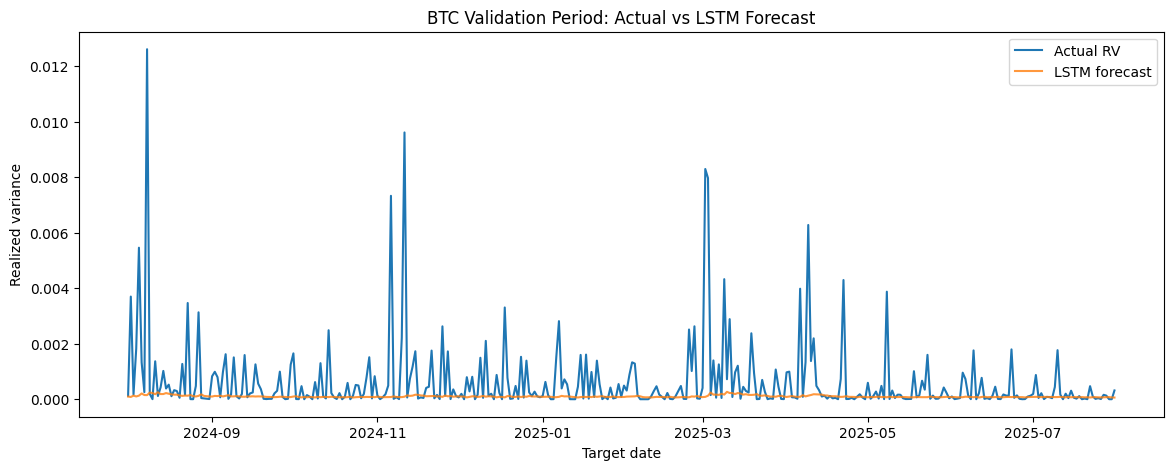

In [24]:
plt.figure(figsize=(14, 5))

plt.plot(
    lstm_predictions_df["target_date"],
    lstm_predictions_df["actual_rv"],
    label="Actual RV"
)

plt.plot(
    lstm_predictions_df["target_date"],
    lstm_predictions_df["lstm_pred_rv"],
    label="LSTM forecast",
    alpha=0.8
)

plt.xlabel("Target date")
plt.ylabel("Realized variance")
plt.title(
    "BTC Validation Period: "
    "Actual vs LSTM Forecast"
)

plt.legend()
plt.show()

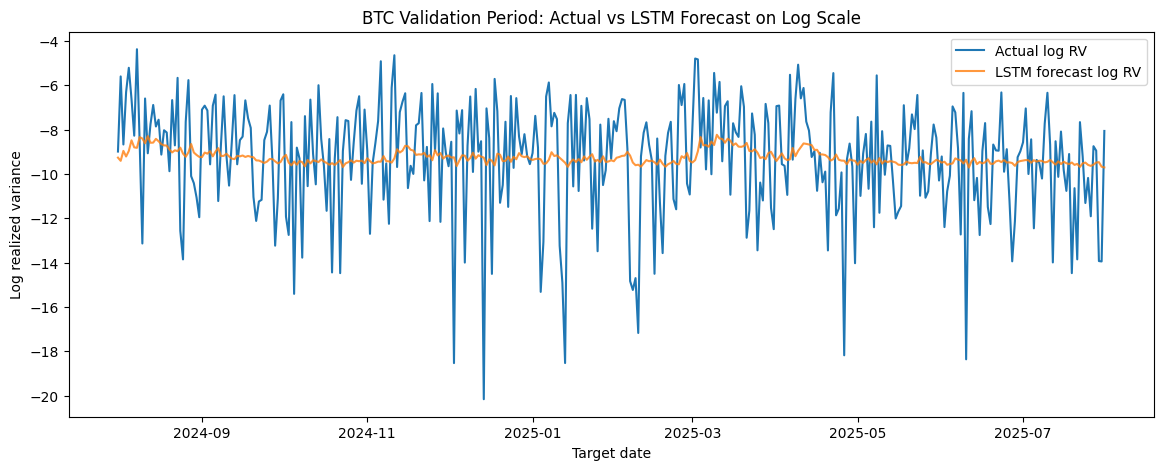

In [25]:
plt.figure(figsize=(14, 5))

plt.plot(
    lstm_predictions_df["target_date"],
    lstm_predictions_df["actual_log_rv"],
    label="Actual log RV"
)

plt.plot(
    lstm_predictions_df["target_date"],
    lstm_predictions_df["lstm_pred_log_rv"],
    label="LSTM forecast log RV",
    alpha=0.8
)

plt.xlabel("Target date")
plt.ylabel("Log realized variance")
plt.title(
    "BTC Validation Period: "
    "Actual vs LSTM Forecast on Log Scale"
)

plt.legend()
plt.show()

### Final Comparison Check

In [26]:

# ---------------------------------------------------------
# Consolidate validation metrics across all lookback windows
# ---------------------------------------------------------

LOOKBACK_OPTIONS = [7, 14, 30]
MODEL_NAMES = ["MLP", "GRU", "LSTM"]

# This should already exist earlier in the notebook.
# It is redefined here so this cell can run independently.
shared_project_dir = Path(
    "/content/drive/MyDrive/Quant Research"
)

btc_results_root = (
    shared_project_dir
    / "results"
    / "BTCUSDT"
)

metric_filename_map = {
    "MLP": "mlp_validation_metrics.csv",
    "GRU": "gru_validation_metrics.csv",
    "LSTM": "lstm_validation_metrics.csv",
}

comparison_rows = []

# ---------------------------------------------------------
# 1. Load simple baseline results
# ---------------------------------------------------------

baseline_metrics_path = (
    btc_results_root
    / "baseline_validation_metrics.csv"
)

if not baseline_metrics_path.exists():
    raise FileNotFoundError(
        f"Baseline metrics file not found:\n"
        f"{baseline_metrics_path}"
    )

baseline_df = pd.read_csv(
    baseline_metrics_path
)

required_metric_columns = {
    "model",
    "mae",
    "rmse",
    "qlike",
}

missing_baseline_columns = (
    required_metric_columns
    - set(baseline_df.columns)
)

if missing_baseline_columns:
    raise ValueError(
        "Baseline metrics file is missing columns: "
        f"{missing_baseline_columns}"
    )

for _, row in baseline_df.iterrows():
    comparison_rows.append({
        "model": row["model"],
        "model_family": "Baseline",
        "lookback_days": np.nan,
        "mae": float(row["mae"]),
        "rmse": float(row["rmse"]),
        "qlike": float(row["qlike"]),
        "metrics_file": str(
            baseline_metrics_path
        ),
    })

# ---------------------------------------------------------
# 2. Load MLP, GRU and LSTM results for 7d, 14d and 30d
# ---------------------------------------------------------

missing_files = []

for lookback_days in LOOKBACK_OPTIONS:

    for model_name in MODEL_NAMES:

        metrics_path = (
            btc_results_root
            / f"lookback_{lookback_days}d"
            / model_name
            / metric_filename_map[model_name]
        )

        if not metrics_path.exists():
            missing_files.append(
                str(metrics_path)
            )
            continue

        model_metrics_df = pd.read_csv(
            metrics_path
        )

        missing_columns = (
            required_metric_columns
            - set(model_metrics_df.columns)
        )

        if missing_columns:
            raise ValueError(
                f"{metrics_path} is missing columns: "
                f"{missing_columns}"
            )

        if len(model_metrics_df) != 1:
            raise ValueError(
                f"Expected exactly one metrics row in "
                f"{metrics_path}, but found "
                f"{len(model_metrics_df)} rows."
            )

        metric_row = model_metrics_df.iloc[0]

        comparison_rows.append({
            "model": (
                f"{model_name}-{lookback_days}d"
            ),
            "model_family": model_name,
            "lookback_days": lookback_days,
            "mae": float(
                metric_row["mae"]
            ),
            "rmse": float(
                metric_row["rmse"]
            ),
            "qlike": float(
                metric_row["qlike"]
            ),
            "metrics_file": str(
                metrics_path
            ),
        })

# Fail clearly if any expected model result is missing.
if missing_files:
    missing_file_message = "\n".join(
        missing_files
    )

    raise FileNotFoundError(
        "The following expected metrics files "
        "were not found:\n\n"
        f"{missing_file_message}\n\n"
        "Run the corresponding model notebooks "
        "for those lookback periods first."
    )

# ---------------------------------------------------------
# 3. Build and validate final comparison dataframe
# ---------------------------------------------------------

final_comparison_df = pd.DataFrame(
    comparison_rows
)

metric_columns = [
    "mae",
    "rmse",
    "qlike",
]

if final_comparison_df[
    metric_columns
].isna().any().any():
    raise ValueError(
        "Missing values found in one or more "
        "evaluation metrics."
    )

if not np.isfinite(
    final_comparison_df[
        metric_columns
    ].to_numpy()
).all():
    raise ValueError(
        "Non-finite values found in the "
        "evaluation metrics."
    )

# Remove accidental duplicate records, if any.
final_comparison_df = (
    final_comparison_df
    .drop_duplicates(
        subset=[
            "model",
            "lookback_days",
        ],
        keep="last"
    )
)

# Rank primarily by QLIKE.
# MAE and RMSE act as tie-breakers.
final_comparison_df = (
    final_comparison_df
    .sort_values(
        by=[
            "qlike",
            "mae",
            "rmse",
        ],
        ascending=True
    )
    .reset_index(drop=True)
)

final_comparison_df.insert(
    0,
    "qlike_rank",
    np.arange(
        1,
        len(final_comparison_df) + 1
    )
)

# Add separate ranks for all metrics.
final_comparison_df[
    "mae_rank"
] = (
    final_comparison_df["mae"]
    .rank(
        method="min",
        ascending=True
    )
    .astype(int)
)

final_comparison_df[
    "rmse_rank"
] = (
    final_comparison_df["rmse"]
    .rank(
        method="min",
        ascending=True
    )
    .astype(int)
)

# Percentage improvement relative to the best
# simple baseline, based on QLIKE.
baseline_only_df = (
    final_comparison_df.loc[
        final_comparison_df[
            "model_family"
        ].eq("Baseline")
    ]
)

best_baseline_qlike = (
    baseline_only_df["qlike"].min()
)

final_comparison_df[
    "qlike_improvement_vs_best_baseline_pct"
] = (
    (
        best_baseline_qlike
        - final_comparison_df["qlike"]
    )
    / best_baseline_qlike
    * 100
)

# Positive value = better than the strongest baseline.
# Negative value = worse than the strongest baseline.

# Organize displayed columns.
display_columns = [
    "qlike_rank",
    "model",
    "model_family",
    "lookback_days",
    "mae",
    "rmse",
    "qlike",
    "qlike_improvement_vs_best_baseline_pct",
    "mae_rank",
    "rmse_rank",
]

final_comparison_df = (
    final_comparison_df[
        display_columns
    ]
)

# ---------------------------------------------------------
# 4. Save final table
# ---------------------------------------------------------

final_comparison_output_path = (
    btc_results_root
    / "final_validation_model_comparison.csv"
)

final_comparison_df.to_csv(
    final_comparison_output_path,
    index=False
)

# ---------------------------------------------------------
# 5. Display final results
# ---------------------------------------------------------

display(
    final_comparison_df.style.format({
        "lookback_days": (
            lambda value:
            ""
            if pd.isna(value)
            else f"{int(value)}"
        ),
        "mae": "{:.8f}",
        "rmse": "{:.8f}",
        "qlike": "{:.6f}",
        "qlike_improvement_vs_best_baseline_pct":
            "{:+.2f}%",
    })
)

best_model_row = (
    final_comparison_df.iloc[0]
)

print(
    "\nBest validation model by QLIKE:"
)

print(
    f"Model: {best_model_row['model']}"
)

print(
    f"QLIKE: "
    f"{best_model_row['qlike']:.6f}"
)

print(
    f"MAE: "
    f"{best_model_row['mae']:.8f}"
)

print(
    f"RMSE: "
    f"{best_model_row['rmse']:.8f}"
)

print(
    "\nFinal comparison saved to:"
)

print(
    final_comparison_output_path
)

,qlike_rank,model,model_family,lookback_days,mae,rmse,qlike,qlike_improvement_vs_best_baseline_pct,mae_rank,rmse_rank
0,1,30-Day Mean RV,Baseline,,0.00073064,0.00135501,1.878815,+0.00%,10,1
1,2,7-Day Mean RV,Baseline,,0.00076783,0.00137714,2.160473,-14.99%,11,2
2,3,MLP-30d,MLP,30,0.00059206,0.00139666,4.627228,-146.28%,9,3
3,4,LSTM-14d,LSTM,14,0.00057520,0.00141746,4.738927,-152.23%,1,6
4,5,LSTM-7d,LSTM,7,0.00058015,0.00142149,4.832544,-157.21%,3,8
5,6,GRU-7d,GRU,7,0.00057947,0.00141488,4.925452,-162.16%,2,5
6,7,GRU-14d,GRU,14,0.00058240,0.00143357,5.248540,-179.35%,5,9
7,8,LSTM-30d,LSTM,30,0.00058228,0.00143365,5.361597,-185.37%,4,10
8,9,GRU-30d,GRU,30,0.00058382,0.00143555,5.515649,-193.57%,6,11
9,10,MLP-7d,MLP,7,0.00058927,0.00141912,6.082799,-223.76%,7,7



Best validation model by QLIKE:
Model: 30-Day Mean RV
QLIKE: 1.878815
MAE: 0.00073064
RMSE: 0.00135501

Final comparison saved to:
/content/drive/MyDrive/Quant Research/results/BTCUSDT/final_validation_model_comparison.csv
